In [4]:

import sys, os

PROJECT_ROOT = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen"
SEG_RDM_ROOT = f"{PROJECT_ROOT}/scripts/SEG-RDM"

if SEG_RDM_ROOT not in sys.path:
    sys.path.insert(0, SEG_RDM_ROOT)

print("sys.path[0]:", sys.path[0])
print("Python:", sys.version.split()[0])


sys.path[0]: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM
Python: 3.9.23


In [5]:

# ── Real training settings (mirrors submit_rdm_train.sh exactly) ─────────────
PROJECT_ROOT = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen"
RDM_ROOT     = f"{PROJECT_ROOT}/scripts/SEG-RDM/rdm"
RUN_DIR      = f"{RDM_ROOT}/rdm_out_final/IJEPA_local_feat/debug"

os.makedirs(RUN_DIR, exist_ok=True)

args_dict = dict(
    # ── paths ────────────────────────────────────────────────────────────────
    data_path         = f"{PROJECT_ROOT}/dataset/imagenet-1K-hf",
    h5_path           = f"{PROJECT_ROOT}/h5_embeddings/region_emb_flat.h5",
    ijepa_h5_path     = f"{PROJECT_ROOT}/h5_embeddings/ijepa_emb_flat.h5",
    ijepa_lookup_json = f"{PROJECT_ROOT}/h5_embeddings/ijepa_lookup.json",
    mask_npz_dir      = None,          # flat H5 mode — no NPZ dir needed
    max_segments      = 250,
    emb_source        = "region",

    # ── model ─────────────────────────────────────────────────────────────────
    config            = f"{RDM_ROOT}/configs/unified_seg_rdm_region_ijepa.yaml",
    input_size        = 256,

    # ── training (debug-friendly values) ─────────────────────────────────────
    batch_size        = 2,             # small for debug
    accum_iter        = 1,
    blr               = 5e-7,
    min_lr            = 1e-6,
    cosine_lr         = True,
    warmup_epochs     = 5,
    weight_decay      = 0.01,
    epochs            = 200,
    num_workers       = 0,             # 0 = no multiprocessing in notebook
    output_dir        = RUN_DIR,
    log_dir           = RUN_DIR,

    # ── distributed (single GPU in notebook) ─────────────────────────────────
    world_size        = 1,
    rank              = 0,
    local_rank        = 0,
    dist_url          = "env://",
    device            = "cuda" if __import__("torch").cuda.is_available() else "cpu",
    seed              = 42,
    resume            = "",
)

print("Settings ready.")
print(f"  Region H5     : {args_dict['h5_path']}")
print(f"  IJEPA H5      : {args_dict['ijepa_h5_path']}")
print(f"  IJEPA lookup  : {args_dict['ijepa_lookup_json']}")
print(f"  Data path     : {args_dict['data_path']}")
print(f"  Device        : {args_dict['device']}")
print(f"  Batch size    : {args_dict['batch_size']}")


Settings ready.
  Region H5     : /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_emb_flat.h5
  IJEPA H5      : /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_emb_flat.h5
  IJEPA lookup  : /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_lookup.json
  Data path     : /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/imagenet-1K-hf
  Device        : cuda
  Batch size    : 2


In [6]:

# ── Build dataset ─────────────────────────────────────────────────────────────
from rdm.data.seg_dataset import SegmentationMaskDataset

ds = SegmentationMaskDataset(
    image_dir         = os.path.join(args_dict["data_path"], "train"),
    mask_npz_dir      = args_dict["mask_npz_dir"],
    max_segments      = args_dict["max_segments"],
    image_size        = args_dict["input_size"],
    emb_source        = args_dict["emb_source"],
    h5_path           = args_dict["h5_path"],
    ijepa_h5_path     = args_dict["ijepa_h5_path"],
    ijepa_lookup_json = args_dict["ijepa_lookup_json"],
    normalize         = True,
)

print(f"\nDataset size : {len(ds):,} samples")

# ── Inspect one sample ────────────────────────────────────────────────────────
sample = ds[0]
print("\nSample keys :", list(sample.keys()))
for k, v in sample.items():
    if hasattr(v, "shape"):
        print(f"  {k:20s} shape={v.shape}  dtype={v.dtype}")
    else:
        print(f"  {k:20s} {v}")


Using flat .h5 file: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_emb_flat.h5
Using flat IJEPA h5 with lookup: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_lookup.json (1281167 entries, loaded in 0.9s)
Building image lookup table from /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/imagenet-1K-hf/train...
  Found 1281167 images
[Flat H5 discovery] Reading index from /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_emb_flat.h5 ...
  Indexed 510172 samples in 63.2s
  Matched 510172/1281167 images in 66.6s (39.8% coverage)
SegmentationMaskDataset: Loaded 510172 images with region embeddings
  image_dir: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/imagenet-1K-hf/train
  mask_npz_dir: None
  h5_path: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_emb_flat.h5
  max_segments: 250
  emb_source: region

Dataset size : 510,172 samples

Sample keys : ['image', 'seg_embs', 'num_

In [8]:

# ── Build DataLoader and pull one batch ───────────────────────────────────────
import torch
from torch.utils.data import DataLoader
from rdm.data.seg_dataset import collate_seg_batch

loader = DataLoader(
    ds,
    batch_size  = args_dict["batch_size"],
    shuffle     = True,
    num_workers = args_dict["num_workers"],
    collate_fn  = collate_seg_batch,
    pin_memory  = False,
)

batch = next(iter(loader))

print("Batch keys:", list(batch.keys()))
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:20s} shape={list(v.shape)}  dtype={v.dtype}")
    else:
        print(f"  {k:20s} {v}")


Batch keys: ['image', 'seg_embs', 'num_segments', 'scores', 'filename', 'emb_source', 'ijepa_emb']
  image                shape=[2, 3, 256, 256]  dtype=torch.float32
  seg_embs             shape=[2, 250, 256]  dtype=torch.float32
  num_segments         shape=[2]  dtype=torch.int64
  scores               shape=[2, 42]  dtype=torch.float32
  filename             ['337159', '122474']
  emb_source           region
  ijepa_emb            shape=[2, 1280]  dtype=torch.float32


In [9]:

# ── Build model from the real config ─────────────────────────────────────────
from omegaconf import OmegaConf
from rdm import util

config = OmegaConf.load(args_dict["config"])
print("Config loaded:", args_dict["config"])
print("Model target :", config.model.target)

device = torch.device(args_dict["device"])
model  = util.instantiate_from_config(config.model)
model  = model.to(device)
model.train()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel parameters : {n_params:,}")
print(f"Running on       : {device}")


[env] module=rdm.util
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] numpy=1.20.3
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501
Config loaded: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/configs/unified_seg_rdm_region_ijepa.yaml
Model target : rdm.models.diffusion.ddpm.UnifiedSegRDM
[env] module=rdm.models.diffusion
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.moco_v3
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.moco_v3.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501


/home/abelde/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[env] module=rdm.pretrained_enc.dino
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.dino.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501
[env] module=rdm.pretrained_enc.ibot
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.ibot.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501
[env] module=rdm.pretrained_enc.deit
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.deit.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501
[env] module=rdm.pr

/home/abelde/.local/lib/python3.9/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/pretrained_enc/deit/vits.py:70: UserWarning: Overwriting deit_tiny_patch16_224 in registry with rdm.pretrained_enc.deit.vits.deit_tiny_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def deit_tiny_patch16_224(pretrained=False, **kwargs):
/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/pretrained_enc/deit/vits.py:85: UserWarning: Overwriting deit_small_patch16_224 in registry with rdm.pretrained_enc.deit.vits.deit_small_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  

DiffusionWrapper has 63.72 M params.
Keeping EMAs of 110.
Training UnifiedSegRDM as an unconditional model.
UnifiedSegRDM: max_segments=250, seg_npz_dir=None
  Diversity loss weight: 0.05
  Alignment loss weight: 0.05
  Normalize SAM tokens: False
  Embedding source: sam
  Alignment projection: 256 -> 256 (trainable=False)

Model parameters : 64,047,872
Running on       : cuda


In [10]:

# ── Optimizer + one forward pass ─────────────────────────────────────────────
import math

total_batch = args_dict["batch_size"] * args_dict["world_size"]
lr = args_dict["blr"] * total_batch
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=args_dict["weight_decay"])

# Move batch to device
batch_gpu = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

optimizer.zero_grad()
loss, loss_dict = model(x=None, c=None, batch=batch_gpu)
loss.backward()
optimizer.step()

print("Forward + backward pass OK")
print(f"  loss       : {loss.item():.4f}")
print(f"  loss_dict  : { {k: f'{v.item():.4f}' for k, v in loss_dict.items()} }")


Forward + backward pass OK
  loss       : 251.5987
  loss_dict  : {'train/loss_simple': '250.8733', 'train/loss_vlb': '10.2388', 'train/loss_diversity': '13.8155', 'train/loss_alignment': '0.6931', 'train/loss': '251.5987'}


In [11]:

# ── Debug training loop — 10 steps with real settings ─────────────────────────
import time

DEBUG_STEPS = 10
model.train()
optimizer.zero_grad()

print(f"Running {DEBUG_STEPS} debug steps  (batch_size={args_dict['batch_size']}, device={device})\n")
t0 = time.time()

for step, batch in enumerate(loader):
    if step >= DEBUG_STEPS:
        break

    batch_gpu = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

    optimizer.zero_grad()
    loss, loss_dict = model(x=None, c=None, batch=batch_gpu)
    loss.backward()

    # gradient clip (same as engine_rdm.py)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    elapsed = time.time() - t0
    loss_str = "  ".join(f"{k}={v.item():.4f}" for k, v in loss_dict.items())
    print(f"  step {step+1:02d}/{DEBUG_STEPS}  loss={loss.item():.4f}  {loss_str}  [{elapsed:.1f}s]")

print(f"\nDone. {DEBUG_STEPS} steps in {time.time()-t0:.1f}s")


Running 10 debug steps  (batch_size=2, device=cuda)

  step 01/10  loss=313.9642  train/loss_simple=313.2506  train/loss_vlb=61.6607  train/loss_diversity=13.5856  train/loss_alignment=0.6856  train/loss=313.9642  [0.9s]
  step 02/10  loss=311.2601  train/loss_simple=310.5510  train/loss_vlb=13.9490  train/loss_diversity=13.5002  train/loss_alignment=0.6819  train/loss=311.2601  [1.4s]
  step 03/10  loss=200.2580  train/loss_simple=199.5482  train/loss_vlb=39.6096  train/loss_diversity=13.5056  train/loss_alignment=0.6913  train/loss=200.2580  [1.9s]
  step 04/10  loss=226.5113  train/loss_simple=225.7946  train/loss_vlb=75.8718  train/loss_diversity=13.6426  train/loss_alignment=0.6927  train/loss=226.5113  [2.5s]
  step 05/10  loss=267.7278  train/loss_simple=267.0136  train/loss_vlb=114.3460  train/loss_diversity=13.5951  train/loss_alignment=0.6900  train/loss=267.7278  [2.9s]
  step 06/10  loss=222.4568  train/loss_simple=221.7424  train/loss_vlb=38.8521  train/loss_diversity=13.5

[env] module=rdm
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.util
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] numpy=1.20.3
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501
Device: cuda
Checkpoint: checkpoint-last.pth
[env] module=rdm.models.diffusion
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]


/home/abelde/.local/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


[env] module=rdm.pretrained_enc.moco_v3
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.moco_v3.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501


/home/abelde/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[env] module=rdm.pretrained_enc.dino
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.dino.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501
[env] module=rdm.pretrained_enc.ibot
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.ibot.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501
[env] module=rdm.pretrained_enc.deit
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.deit.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501
[env] module=rdm.pr

/home/abelde/.local/lib/python3.9/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/pretrained_enc/deit/vits.py:70: UserWarning: Overwriting deit_tiny_patch16_224 in registry with rdm.pretrained_enc.deit.vits.deit_tiny_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def deit_tiny_patch16_224(pretrained=False, **kwargs):
/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/pretrained_enc/deit/vits.py:85: UserWarning: Overwriting deit_small_patch16_224 in registry with rdm.pretrained_enc.deit.vits.deit_small_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  

DiffusionWrapper has 63.72 M params.
Keeping EMAs of 110.
Training UnifiedSegRDM as an unconditional model.
UnifiedSegRDM: max_segments=250, seg_npz_dir=None
  Diversity loss weight: 0.05
  Alignment loss weight: 0.05
  Normalize SAM tokens: False
  Embedding source: sam
  Alignment projection: 256 -> 256 (trainable=False)

Checkpoint loaded. Missing: 0  Unexpected: 0
Model: seq_len=251, channels=256, timesteps=1000

Sampling 64 sequences with DDIM (50 steps)...
Selected timesteps for ddim sampler: [  1  21  41  61  81 101 121 141 161 181 201 221 241 261 281 301 321 341
 361 381 401 421 441 461 481 501 521 541 561 581 601 621 641 661 681 701
 721 741 761 781 801 821 841 861 881 901 921 941 961 981]
Selected alphas for ddim sampler: a_t: tensor([0.9998, 0.9971, 0.9931, 0.9876, 0.9801, 0.9706, 0.9589, 0.9447, 0.9279,
        0.9084, 0.8862, 0.8611, 0.8334, 0.8030, 0.7700, 0.7348, 0.6976, 0.6585,
        0.6181, 0.5766, 0.5345, 0.4922, 0.4501, 0.4087, 0.3683, 0.3294, 0.2922,
        0.257

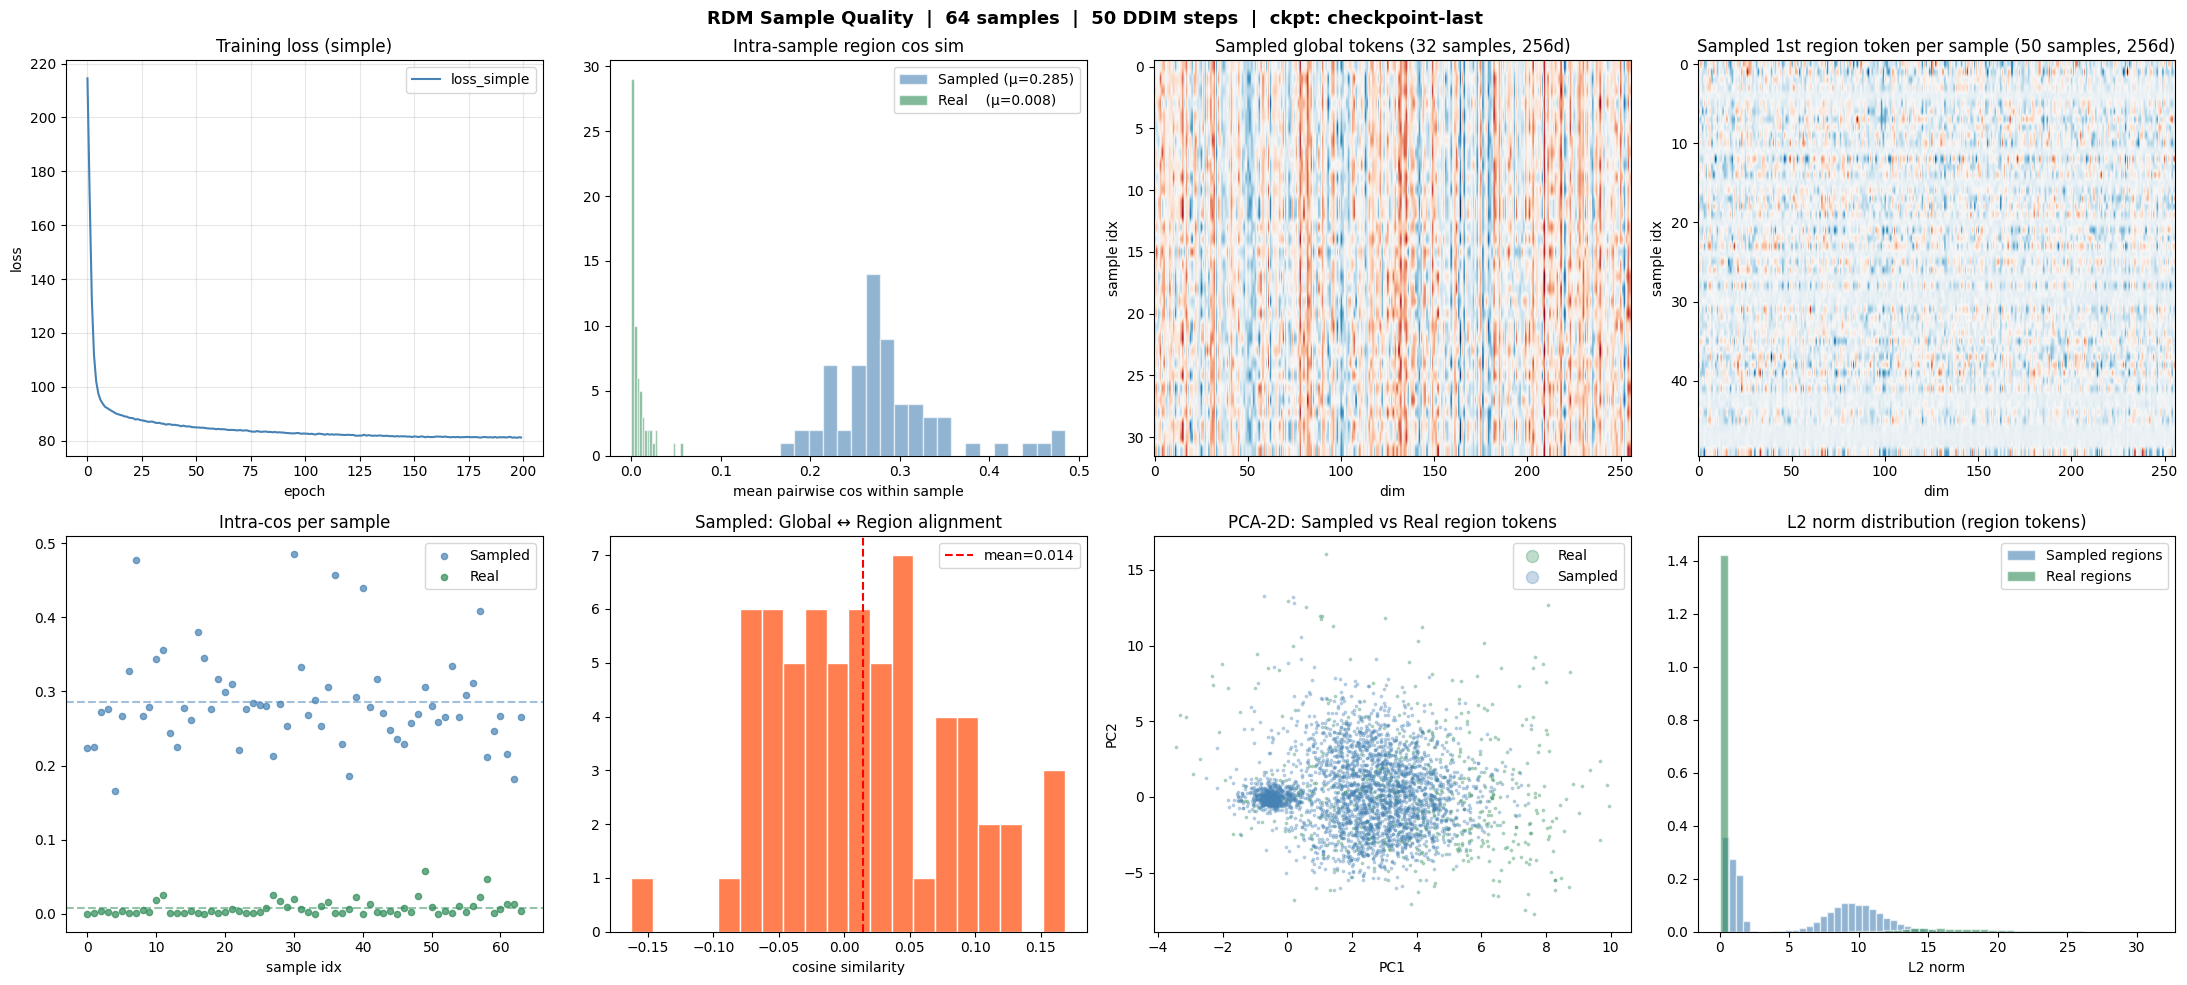


SUMMARY
  Region eff_rank (sampled):      61.7 / 256  (24.1%)
  Region inter-cos (sampled):     0.066  (real: 0.001)
  Region intra-cos (sampled):     0.285  (real: 0.008)
  Global eff_rank (sampled):      7.0 / 256  (2.7%)
  Global inter-cos (sampled):     0.575  (real: 0.434)
  Global↔Region align (sampled):  0.014

What to look for:
  Region inter-cos  → close to real (~0.04) = good coverage
  Region intra-cos  → close to real (~0.32) = coherent within sample
  Global inter-cos  → close to real means diverse global tokens
  PCA overlap       → sampled cloud covers real cloud = good manifold match


In [1]:
# ============================================================
# RDM Sample Quality Analysis
#
# Loads the best checkpoint, draws N samples, and asks:
#   1. Distribution match  – do sampled token STATS match real H5 tokens?
#   2. Diversity           – are different samples diverse (eff_rank, cos sim)?
#   3. Intra-sample spread – within one sample, are region tokens distinct?
#   4. Coverage (PCA)      – do samples cover the real-data manifold?
#   5. Global↔Region align – does the sampled CLS relate to region tokens?
#   6. Training curve      – loss vs epoch from log.txt
# ============================================================
import os, sys, json, re
import numpy as np
import h5py
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from sklearn.decomposition import PCA

PROJECT_ROOT = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen"
SEG_RDM_ROOT = f"{PROJECT_ROOT}/scripts/SEG-RDM"
if SEG_RDM_ROOT not in sys.path:
    sys.path.insert(0, SEG_RDM_ROOT)

from rdm import util

# ── Config ───────────────────────────────────────────────────────────────────
RDM_ROOT   = f"{SEG_RDM_ROOT}/rdm"
CKPT       = f"{RDM_ROOT}/rdm_out_final/IJEPA_local_feat/a100-rerun/2_nodes/checkpoint-last.pth"
CONFIG     = f"{RDM_ROOT}/configs/unified_seg_rdm_region_ijepa.yaml"
LOG_TXT    = f"{RDM_ROOT}/rdm_out_final/IJEPA_local_feat/a100-rerun/2_nodes/log.txt"
H5_REGION  = f"{PROJECT_ROOT}/h5_embeddings/region_emb_flat.h5"
H5_IJEPA   = f"{PROJECT_ROOT}/h5_embeddings/ijepa_emb_flat.h5"

N_SAMPLES  = 64     # number of RDM samples to draw
DDIM_STEPS = 50     # DDIM steps (fast); set to 250 for higher quality
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"Checkpoint: {os.path.basename(CKPT)}")

# ── Helper functions ──────────────────────────────────────────────────────────

def effective_rank(x: np.ndarray, eps=1e-12) -> float:
    x = x.astype(np.float64)
    x -= x.mean(0, keepdims=True)
    cov = (x.T @ x) / max(1, x.shape[0] - 1)
    ev = np.linalg.eigvalsh(cov).clip(eps)
    p = ev / ev.sum()
    return float(np.exp(-(p * np.log(p)).sum()))

def cos_stats(x: np.ndarray, max_pairs=30_000) -> dict:
    x = x.astype(np.float32)
    x /= np.linalg.norm(x, axis=1, keepdims=True).clip(1e-8)
    n = x.shape[0]
    rng = np.random.default_rng(42)
    i = rng.integers(0, n, max_pairs); j = rng.integers(0, n, max_pairs)
    mask = i != j
    sims = (x[i[mask]] * x[j[mask]]).sum(1)
    return dict(mean=float(sims.mean()), std=float(sims.std()),
                p05=float(np.percentile(sims,5)), p50=float(np.percentile(sims,50)),
                p95=float(np.percentile(sims,95)))

def intra_cos(tokens: np.ndarray) -> float:
    """tokens: [N_segs, D] — all from one sample."""
    if tokens.shape[0] < 2: return float("nan")
    t = tokens.astype(np.float32)
    t /= np.linalg.norm(t, axis=1, keepdims=True).clip(1e-8)
    sim = t @ t.T
    n = sim.shape[0]
    return float(sim[np.triu_indices(n, k=1)].mean())

# ──────────────────────────────────────────────────────────────────────────────
# 1. LOAD MODEL AND CHECKPOINT
# ──────────────────────────────────────────────────────────────────────────────
config = OmegaConf.load(CONFIG)
model  = util.instantiate_from_config(config.model)
model  = model.to(DEVICE)
model.eval()

# Load checkpoint weights
ckpt_data = torch.load(CKPT, map_location="cpu", weights_only=False)
state_key = "model" if "model" in ckpt_data else "state_dict"
sd = ckpt_data.get(state_key, ckpt_data)
# Strip DDP prefix if present
sd = {k.replace("module.", ""): v for k, v in sd.items()}
missing, unexpected = model.load_state_dict(sd, strict=False)
print(f"\nCheckpoint loaded. Missing: {len(missing)}  Unexpected: {len(unexpected)}")
if missing: print("  Missing (first 5):", missing[:5])
if unexpected: print("  Unexpected (first 5):", unexpected[:5])

SEQ_LEN  = model.image_size   # 251 = 1 global + 250 region
CHANNELS = model.channels      # 256 (matches checkpoint)
print(f"Model: seq_len={SEQ_LEN}, channels={CHANNELS}, timesteps={model.num_timesteps}")

# ──────────────────────────────────────────────────────────────────────────────
# 2. DDIM SAMPLING
# ──────────────────────────────────────────────────────────────────────────────
from rdm.models.diffusion.ddim import DDIMSampler

sampler = DDIMSampler(model)
shape   = (CHANNELS, 1, SEQ_LEN)   # per-sample shape for DDIMSampler

print(f"\nSampling {N_SAMPLES} sequences with DDIM ({DDIM_STEPS} steps)...")
with torch.no_grad():
    samples_raw, _ = sampler.sample(
        S           = DDIM_STEPS,
        batch_size  = N_SAMPLES,
        shape       = shape,
        conditioning= None,
        verbose     = True,
    )
# samples_raw: [N_SAMPLES, CHANNELS, 1, SEQ_LEN]
samples_seq = samples_raw.squeeze(2).permute(0, 2, 1).cpu().numpy()
# samples_seq: [N_SAMPLES, SEQ_LEN, CHANNELS]
print(f"Sampled shape: {samples_seq.shape}")

# Split into global and region tokens
sampled_global  = samples_seq[:, 0, :]          # [N_SAMPLES, 256]
sampled_regions = samples_seq[:, 1:, :]         # [N_SAMPLES, 250, 256]
print(f"  Global tokens  : {sampled_global.shape}")
print(f"  Region tokens  : {sampled_regions.shape}")

# ──────────────────────────────────────────────────────────────────────────────
# 3. LOAD REAL TOKENS FROM H5 FOR COMPARISON
# ──────────────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(0)

with h5py.File(H5_REGION, "r") as f:
    n_imgs   = f["offsets"].shape[0]
    sample_i = np.sort(rng.choice(n_imgs, N_SAMPLES, replace=False))
    real_regions_list = []
    for i in sample_i:
        ns  = int(f["n_segments"][i])
        off = int(f["offsets"][i])
        real_regions_list.append(f["emb"][off:off+min(ns, 250)])
    # Pad each to 250 for stacking
    real_regions = np.zeros((N_SAMPLES, 250, 256), dtype=np.float32)
    for j, r in enumerate(real_regions_list):
        real_regions[j, :r.shape[0]] = r

with h5py.File(H5_IJEPA, "r") as f:
    cls_i = np.sort(rng.choice(f["emb"].shape[0], N_SAMPLES, replace=False))
    real_global = f["emb"][cls_i]              # [N_SAMPLES, 1280]

print(f"\nReal global tokens  : {real_global.shape}")
print(f"Real region tokens  : {real_regions.shape}")

# ──────────────────────────────────────────────────────────────────────────────
# 4. METRIC COMPARISON
# ──────────────────────────────────────────────────────────────────────────────
REAL_GLOBAL_DIM = real_global.shape[1]  # 1280 (I-JEPA mean-pool)
REAL_REGION_DIM = 256

print("\n" + "="*60)
print("METRIC COMPARISON: Sampled vs Real")
print("="*60)

# --- Global tokens ---
print("\nGlobal / CLS token:")
print(f"  {'Metric':<28}  {'Sampled (256d)':>14}  {'Real (1280d)':>14}")
sr_g  = sampled_global.reshape(-1, CHANNELS)
er_sg = effective_rank(sr_g)
cs_sg = cos_stats(sr_g)
er_rg = effective_rank(real_global)
cs_rg = cos_stats(real_global)
print(f"  {'eff_rank':<28}  {er_sg:>14.1f}  {er_rg:>14.1f}")
print(f"  {'eff_rank %':<28}  {100*er_sg/CHANNELS:>13.1f}%  {100*er_rg/REAL_GLOBAL_DIM:>13.1f}%")
print(f"  {'inter-sample cos mean':<28}  {cs_sg['mean']:>14.3f}  {cs_rg['mean']:>14.3f}")
print(f"  {'inter-sample cos std':<28}  {cs_sg['std']:>14.3f}  {cs_rg['std']:>14.3f}")
print(f"  {'L2 norm mean':<28}  {np.linalg.norm(sr_g,axis=1).mean():>14.3f}  {np.linalg.norm(real_global,axis=1).mean():>14.3f}")
print(f"  {'L2 norm std':<28}  {np.linalg.norm(sr_g,axis=1).std():>14.3f}  {np.linalg.norm(real_global,axis=1).std():>14.3f}")

# --- Region tokens (both 256-dim now!) ---
print("\nRegion tokens (both 256-dim):")
sr_r = sampled_regions.reshape(-1, CHANNELS)   # (N_SAMPLES*250, 256)
rr_r = real_regions.reshape(-1, REAL_REGION_DIM)  # (N_SAMPLES*250, 256)
er_sr = effective_rank(sr_r)
cs_sr = cos_stats(sr_r)
er_rr = effective_rank(rr_r)
cs_rr = cos_stats(rr_r)
print(f"  {'Metric':<28}  {'Sampled':>12}  {'Real':>12}")
print(f"  {'eff_rank':<28}  {er_sr:>12.1f}  {er_rr:>12.1f}")
print(f"  {'eff_rank %':<28}  {100*er_sr/CHANNELS:>11.1f}%  {100*er_rr/REAL_REGION_DIM:>11.1f}%")
print(f"  {'inter-sample cos mean':<28}  {cs_sr['mean']:>12.3f}  {cs_rr['mean']:>12.3f}")
print(f"  {'inter-sample cos std':<28}  {cs_sr['std']:>12.3f}  {cs_rr['std']:>12.3f}")

# --- Intra-sample cosine similarity ---
print("\nIntra-sample region cosine (within one sample):")
intra_sampled = [intra_cos(sampled_regions[i]) for i in range(N_SAMPLES)]
intra_real    = [intra_cos(real_regions[i]) for i in range(N_SAMPLES)]
print(f"  Sampled mean = {np.nanmean(intra_sampled):.3f}  (real = {np.nanmean(intra_real):.3f})")
print(f"  Sampled std  = {np.nanstd(intra_sampled):.3f}  (real = {np.nanstd(intra_real):.3f})")
print("  NOTE: Lower is better (more diverse spatial tokens)")

# ──────────────────────────────────────────────────────────────────────────────
# 5. GLOBAL ↔ REGION ALIGNMENT IN SAMPLED TOKENS
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("Global ↔ Region alignment  (are they consistent within a sample?)")

# Both sampled global and region are 256-dim — can compare directly
# Per-sample: cos(global[i], mean(regions[i]))
align_sims = []
for i in range(N_SAMPLES):
    g = sampled_global[i]
    r_mean = sampled_regions[i].mean(0)
    g_n = g / (np.linalg.norm(g) + 1e-8)
    r_n = r_mean / (np.linalg.norm(r_mean) + 1e-8)
    align_sims.append(float(g_n @ r_n))

print(f"  cos(sampled_global, mean(sampled_region)):  mean={np.mean(align_sims):.3f}  std={np.std(align_sims):.3f}")
print("  (positive = global and regions point in same direction — good)")

# ──────────────────────────────────────────────────────────────────────────────
# 6. PCA COVERAGE: Do samples cover the real-data manifold?
# ──────────────────────────────────────────────────────────────────────────────
# Both sampled and real region tokens are 256-dim — fit PCA on real, project both
pca_shared = PCA(n_components=2, random_state=0)
real_flat_sub = rr_r[rng.choice(len(rr_r), min(5000, len(rr_r)), replace=False)]
smpl_sub = sr_r[rng.choice(len(sr_r), min(5000, len(sr_r)), replace=False)]

pca_shared.fit(real_flat_sub)
r_2d = pca_shared.transform(real_flat_sub)
s_2d = pca_shared.transform(smpl_sub)

# ──────────────────────────────────────────────────────────────────────────────
# 7. TRAINING CURVE
# ──────────────────────────────────────────────────────────────────────────────
epochs_log, loss_simple, loss_diversity, loss_alignment = [], [], [], []
if os.path.exists(LOG_TXT):
    with open(LOG_TXT, "r") as fp:
        for line in fp:
            try:
                d = json.loads(line.strip())
                epochs_log.append(d["epoch"])
                loss_simple.append(d.get("train_train/loss_simple", float("nan")))
                loss_diversity.append(d.get("train_train/loss_diversity", float("nan")))
                loss_alignment.append(d.get("train_train/loss_alignment", float("nan")))
            except: pass
    print(f"\nTraining curve loaded: {len(epochs_log)} epochs")
    print(f"  Final epoch {epochs_log[-1]}:")
    print(f"    loss_simple    = {loss_simple[-1]:.2f}")
    print(f"    loss_diversity = {loss_diversity[-1]:.4f}")
    print(f"    loss_alignment = {loss_alignment[-1]:.4f}")

# ──────────────────────────────────────────────────────────────────────────────
# 8. PLOTS
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# [0,0] Training curve
if epochs_log:
    ax = axes[0, 0]
    ax.plot(epochs_log, loss_simple, label="loss_simple", color="steelblue")
    ax.set_title("Training loss (simple)")
    ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=0.3)

# [0,1] Intra-sample cosine distribution
ax = axes[0, 1]
ax.hist(intra_sampled, bins=20, alpha=0.6, label=f"Sampled (μ={np.nanmean(intra_sampled):.3f})", color="steelblue", edgecolor="white")
ax.hist(intra_real,    bins=20, alpha=0.6, label=f"Real    (μ={np.nanmean(intra_real):.3f})",    color="seagreen",  edgecolor="white")
ax.set_title("Intra-sample region cos sim")
ax.set_xlabel("mean pairwise cos within sample"); ax.legend()

# [0,2] Global token heatmap — sampled
ax = axes[0, 2]
ax.imshow(sampled_global[:32], aspect="auto", cmap="RdBu_r")
ax.set_title(f"Sampled global tokens (32 samples, {CHANNELS}d)")
ax.set_xlabel("dim"); ax.set_ylabel("sample idx")

# [0,3] Region token heatmap — sampled (first 50 tokens across samples)
ax = axes[0, 3]
ax.imshow(sampled_regions[:50, 0, :], aspect="auto", cmap="RdBu_r")
ax.set_title(f"Sampled 1st region token per sample (50 samples, {CHANNELS}d)")
ax.set_xlabel("dim"); ax.set_ylabel("sample idx")

# [1,0] Diversity: per-sample intra cosine vs index
ax = axes[1, 0]
ax.scatter(range(N_SAMPLES), intra_sampled, color="steelblue", s=20, label="Sampled", alpha=0.7)
ax.scatter(range(N_SAMPLES), intra_real,    color="seagreen",  s=20, label="Real",    alpha=0.7)
ax.axhline(np.nanmean(intra_sampled), color="steelblue", linestyle="--", alpha=0.5)
ax.axhline(np.nanmean(intra_real),    color="seagreen",  linestyle="--", alpha=0.5)
ax.set_title("Intra-cos per sample"); ax.set_xlabel("sample idx"); ax.legend()

# [1,1] Global↔Region alignment distribution
ax = axes[1, 1]
ax.hist(align_sims, bins=20, color="coral", edgecolor="white")
ax.axvline(np.mean(align_sims), color="red", linestyle="--", label=f"mean={np.mean(align_sims):.3f}")
ax.set_title("Sampled: Global ↔ Region alignment")
ax.set_xlabel("cosine similarity"); ax.legend()

# [1,2] PCA of sampled region tokens (in real PCA space)
ax = axes[1, 2]
ax.scatter(r_2d[:, 0], r_2d[:, 1], s=3, alpha=0.3, color="seagreen", label="Real")
ax.scatter(s_2d[:, 0], s_2d[:, 1], s=3, alpha=0.3, color="steelblue", label="Sampled")
ax.set_title(f"PCA-2D: Sampled vs Real region tokens")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(markerscale=5)

# [1,3] L2 norm distribution
ax = axes[1, 3]
ax.hist(np.linalg.norm(sr_r, axis=1), bins=50, alpha=0.6, label="Sampled regions", color="steelblue", edgecolor="white", density=True)
ax.hist(np.linalg.norm(rr_r, axis=1), bins=50, alpha=0.6, label="Real regions", color="seagreen", edgecolor="white", density=True)
ax.set_title("L2 norm distribution (region tokens)")
ax.set_xlabel("L2 norm"); ax.legend()

plt.suptitle(f"RDM Sample Quality  |  {N_SAMPLES} samples  |  {DDIM_STEPS} DDIM steps  |  ckpt: checkpoint-last", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"  Region eff_rank (sampled):      {er_sr:.1f} / {CHANNELS}  ({100*er_sr/CHANNELS:.1f}%)")
print(f"  Region inter-cos (sampled):     {cs_sr['mean']:.3f}  (real: {cs_rr['mean']:.3f})")
print(f"  Region intra-cos (sampled):     {np.nanmean(intra_sampled):.3f}  (real: {np.nanmean(intra_real):.3f})")
print(f"  Global eff_rank (sampled):      {er_sg:.1f} / {CHANNELS}  ({100*er_sg/CHANNELS:.1f}%)")
print(f"  Global inter-cos (sampled):     {cs_sg['mean']:.3f}  (real: {cs_rg['mean']:.3f})")
print(f"  Global↔Region align (sampled):  {np.mean(align_sims):.3f}")
print()
print("What to look for:")
print("  Region inter-cos  → close to real (~0.04) = good coverage")
print("  Region intra-cos  → close to real (~0.32) = coherent within sample")
print("  Global inter-cos  → close to real means diverse global tokens")
print("  PCA overlap       → sampled cloud covers real cloud = good manifold match")

In [1]:
# Load model directly
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained("facebook/ijepa_vith14_1k")
model = AutoModel.from_pretrained("facebook/ijepa_vith14_1k")

/home/abelde/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/abelde/.local/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
2026-03-03 23:47:12.610359: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772599632.705517 3716952 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772599632.732322 3716952 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has alrea

In [ ]:
import requests
from PIL import Image
from torch.nn.functional import cosine_similarity

from transformers import AutoModel, AutoProcessor

url_1 = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/imagenet-1K-hf/train/0/229.JPEG"
url_2 = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/imagenet-1K-hf/train/0/980.JPEG"
image_1 = Image.open(url_1)
image_2 = Image.open(url_2)

model_id = "facebook/ijepa_vith14_1k"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id)


def infer(image):
    inputs = processor(image, return_tensors="pt")
    outputs = model(**inputs)
    #Need the shape of the output
    print(outputs.last_hidden_state.shape)
    return outputs.last_hidden_state.mean(dim=1)


embed_1 = infer(image_1)
embed_2 = infer(image_2)

similarity = cosine_similarity(embed_1, embed_2)
print(similarity)


KeyboardInterrupt: 

In [1]:
!nvidia-smi

Wed Mar 25 12:46:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A30                     On  |   00000000:21:00.0 Off |                    0 |
| N/A   32C    P0             30W /  165W |    1241MiB /  24576MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----